# Description

It takes TWAS results on a random phenotype and verifies that the QQ-plots look fine (without inflation).

# Modules

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





# Paths

In [3]:
GLS_NULL_SIMS_DIR <- Sys.getenv("PHENOPLIER_RESULTS_GLS_NULL_SIMS")

In [4]:
GLS_NULL_SIMS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims"

In [5]:
SPREDIXCAN_DIR <- file.path(GLS_NULL_SIMS_DIR, "twas", "spredixcan")

In [6]:
SPREDIXCAN_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/spredixcan"

In [7]:
SMULTIXCAN_DIR <- file.path(GLS_NULL_SIMS_DIR, "twas", "smultixcan")

In [8]:
SMULTIXCAN_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan"

# Random pheno 0

In [9]:
pheno_code <- "0"

## S-PrediXcan

In [10]:
tissue <- "Whole_Blood"

### Load data

In [11]:
twas <- as.data.frame(read_csv(file.path(SPREDIXCAN_DIR, paste0("random.pheno", pheno_code,"-gtex_v8-mashr-", tissue,".csv"))))

Rows: 12594 Columns: 14
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, gene_name
dbl (8): zscore, pvalue, var_g, n_snps_used, n_snps_in_cov, n_snps_in_model,...
lgl (4): effect_size, pred_perf_r2, pred_perf_pval, pred_perf_qval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
dim(twas)

[1] 12594    14

In [13]:
head(twas)

,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model,best_gwas_p,largest_weight
,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000125910.5,S1PR4,-3.949035,NA,7.846694e-05,1.039426e-04,NA,NA,NA,2,2,2,4.075202e-05,0.031807575
2,ENSG00000273759.1,RP4-563E14.1,3.825917,NA,1.302861e-04,6.513172e-02,NA,NA,NA,2,2,2,7.295078e-04,0.604016833
3,ENSG00000163923.9,RPL39L,-3.749734,NA,1.770225e-04,3.699915e-06,NA,NA,NA,1,1,1,1.770225e-04,0.005621311
4,ENSG00000221995.5,TIAF1,-3.683257,NA,2.302723e-04,2.421389e-02,NA,NA,NA,3,3,3,1.779786e-03,0.121188407
5,ENSG00000181788.3,SIAH2,-3.564945,NA,3.639322e-04,1.092966e-03,NA,NA,NA,1,1,1,3.639322e-04,0.165561690
6,ENSG00000139531.12,SUOX,3.480243,NA,5.009586e-04,3.597855e-02,NA,NA,NA,3,3,3,1.167781e-03,0.245873979


### QQ-plot

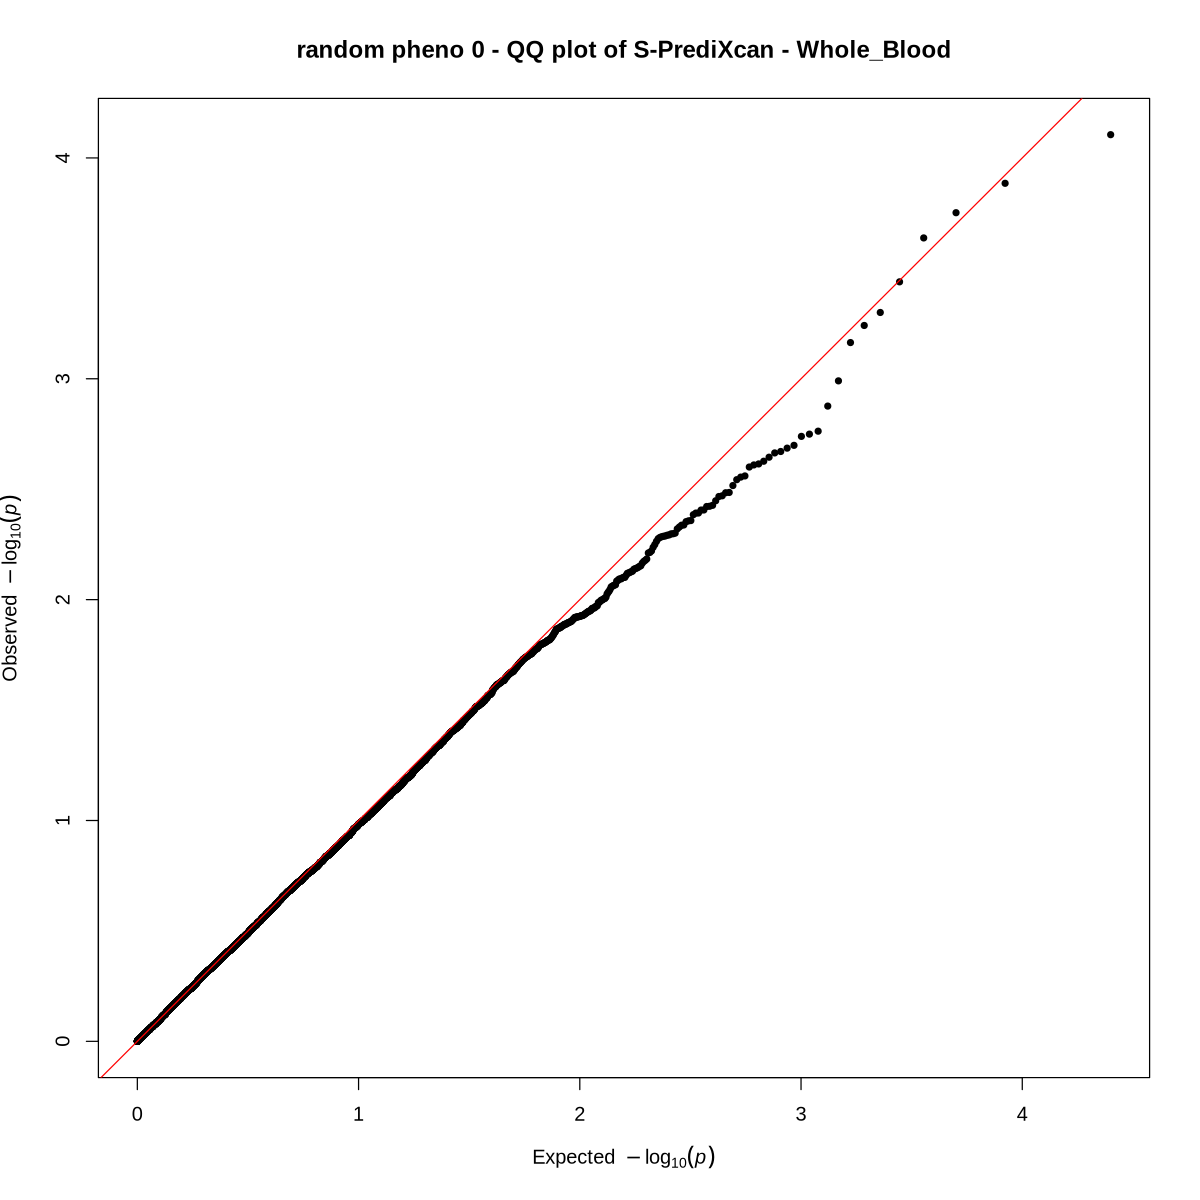

In [15]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-PrediXcan - ", tissue)
)

## S-MultiXcan

### Load data

In [16]:
twas <- as.data.frame(read_table(file.path(SMULTIXCAN_DIR, paste0("random.pheno", pheno_code, "-gtex_v8-mashr-smultixcan.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  gene = col_character(),
  gene_name = col_character(),
  pvalue = col_double(),
  n = col_double(),
  n_indep = col_double(),
  p_i_best = col_double(),
  t_i_best = col_character(),
  p_i_worst = col_double(),
  t_i_worst = col_character(),
  eigen_max = col_double(),
  eigen_min = col_double(),
  eigen_min_kept = col_double(),
  z_min = col_double(),
  z_max = col_double(),
  z_mean = col_double(),
  z_sd = col_double(),
  tmi = col_double(),
  status = col_double()
)



In [17]:
dim(twas)

[1] 22519    18

In [18]:
head(twas)

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000254416.5,RP11-347E10.1,1.656101e-05,4,3,2.444542e-02,Spleen,0.2629156914,Nerve_Tibial,2.612788,1.693280e-02,0.3405801,-1.311768,2.250056,0.2619596,1.758121,3,0
2,ENSG00000271564.1,RP13-444H2.1,3.000779e-04,1,1,3.000779e-04,Testis,0.0003000779,Testis,1.000000,1.000000e+00,1.0000000,-3.615233,-3.615233,-3.6152327,NA,1,0
3,ENSG00000181788.3,SIAH2,4.668467e-04,45,1,4.222948e-05,Muscle_Skeletal,0.0172808571,Thyroid,43.177415,9.963391e-16,43.1774147,-4.094931,3.722543,-1.4779302,3.180245,1,0
4,ENSG00000168830.7,HTR1E,5.215506e-04,18,3,6.650053e-05,Thyroid,0.3840800165,Brain_Hippocampus,9.555565,7.385609e-18,1.1513981,-3.780852,3.988471,0.6381961,1.955544,3,0
5,ENSG00000148734.7,NPFFR1,6.180806e-04,22,6,5.663342e-03,Brain_Hippocampus,0.9735291173,Nerve_Tibial,11.780344,6.448113e-18,0.5202418,-2.766662,2.766662,-0.7094228,1.916941,6,0
6,ENSG00000036054.12,TBC1D23,6.317636e-04,43,3,4.073512e-03,Nerve_Tibial,0.9975946074,Adipose_Subcutaneous,30.779007,6.170009e-16,2.5097780,-2.872412,1.581920,-0.8240583,1.150355,3,0


### QQ-plot

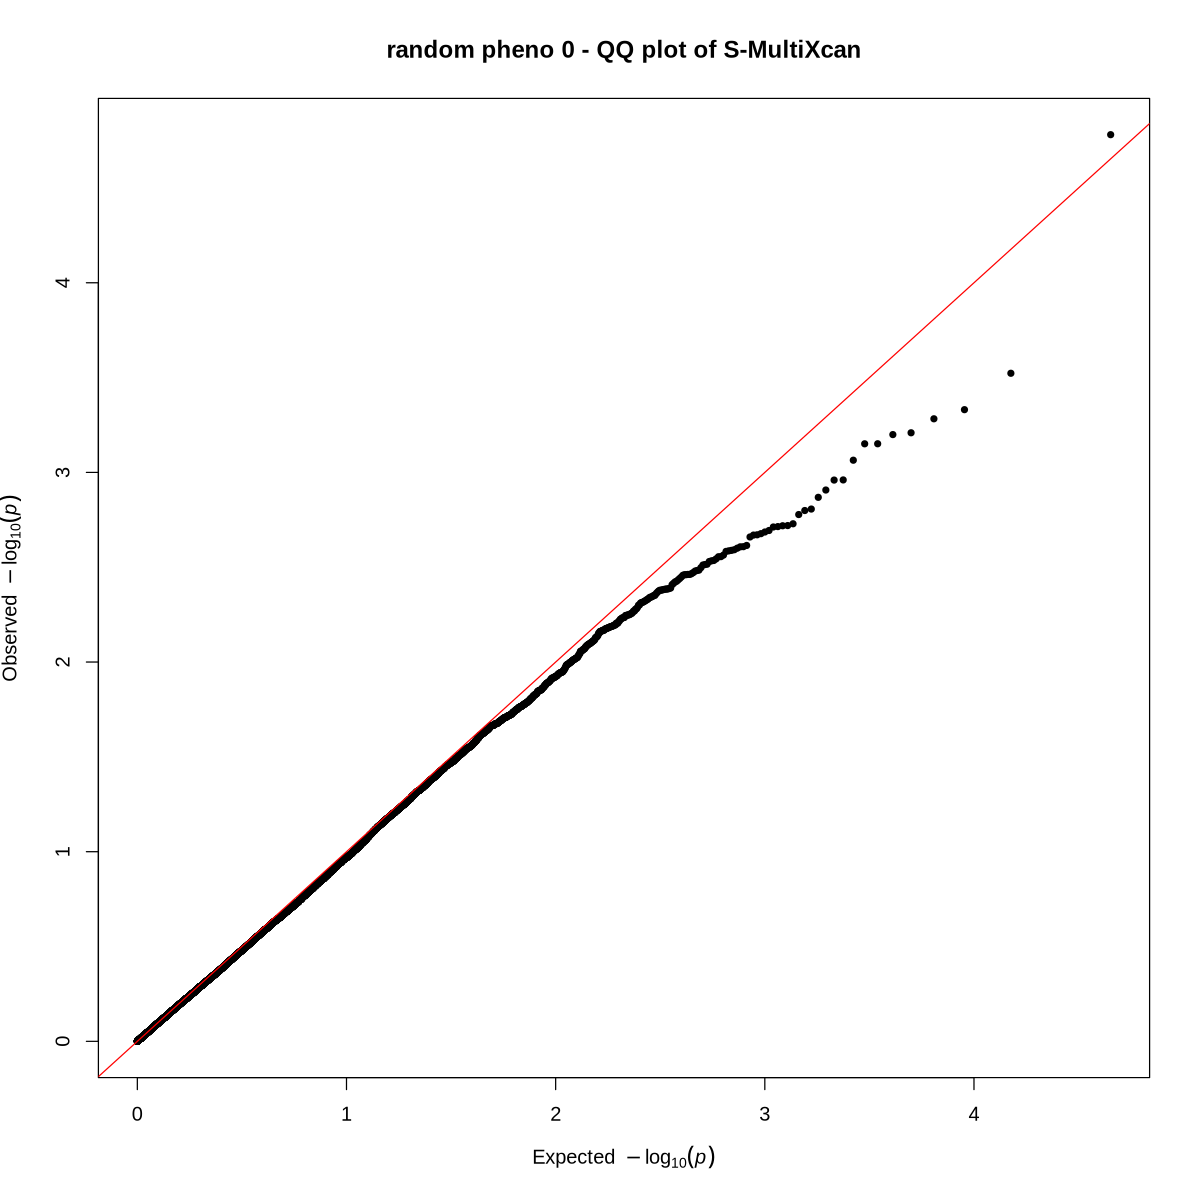

In [19]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-MultiXcan")
)